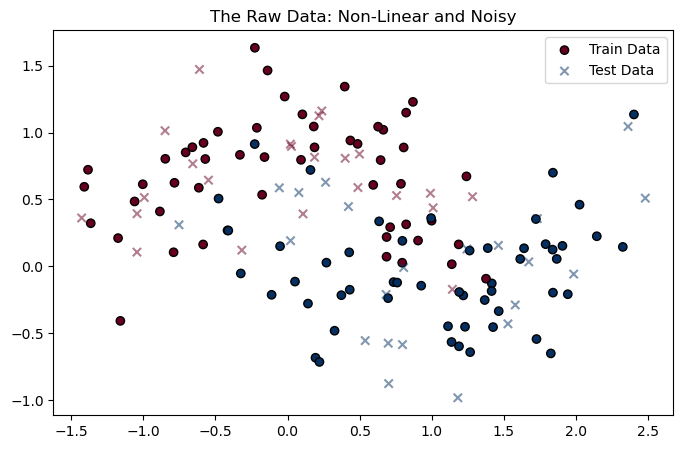

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Generate noisy data
X, y = make_moons(n_samples=150, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Plot the raw data
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', edgecolors='k', label='Train Data')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', marker='x', alpha=0.5, label='Test Data')
plt.title("The Raw Data: Non-Linear and Noisy")
plt.legend()
plt.show()

Précision du modèle (Accuracy) : 0.82


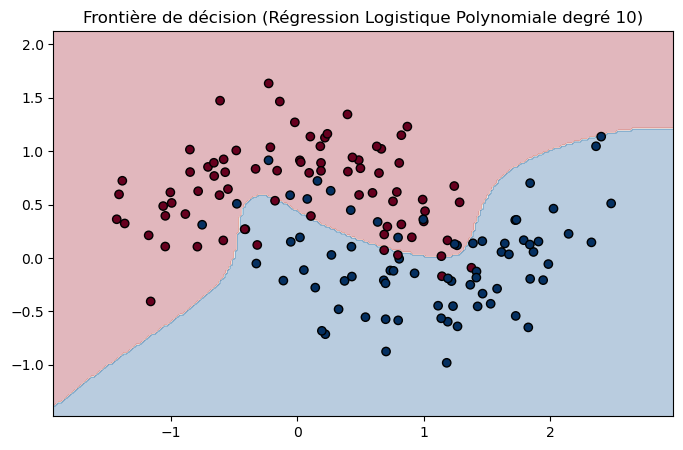

In [3]:
# 1. Préparation du modèle (Pipeline : Standardisation -> Transformation Polynomiale -> Régression)
from sklearn.pipeline import Pipeline

degree = 10 # Degré du polynôme pour capturer la courbure des "moons"

model = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_features", PolynomialFeatures(degree=degree)),
    ("logistic_regression", LogisticRegression())
])

# 2. Entraînement du modèle
model.fit(X_train, y_train)

# 3. Prédictions et évaluation
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Précision du modèle (Accuracy) : {accuracy:.2f}")

# 4. Visualisation de la frontière de décision
def plot_decision_boundary(clf, X):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')

plt.figure(figsize=(8, 5))
plot_decision_boundary(model, X)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdBu', edgecolors='k')
plt.title(f"Frontière de décision (Régression Logistique Polynomiale degré {degree})")
plt.show()

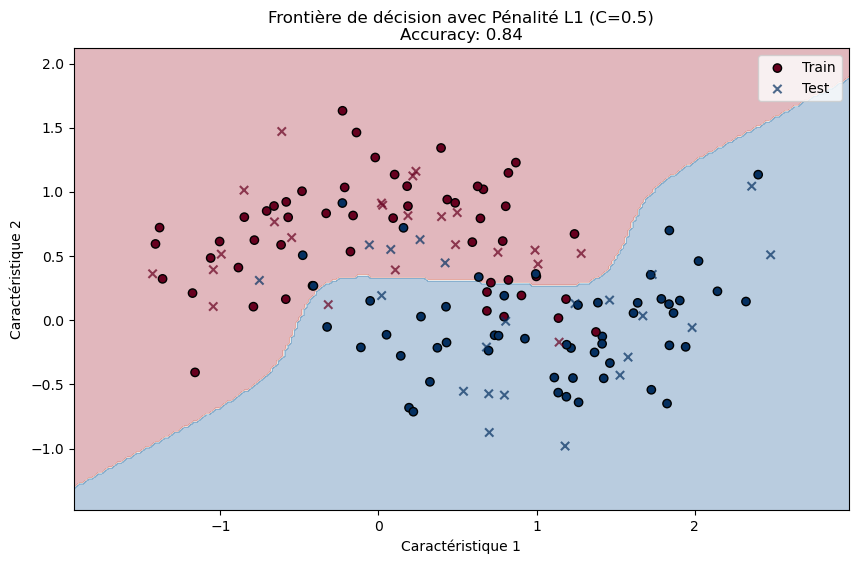

Nombre de coefficients totaux : 66
Nombre de coefficients annulés par L1 : 60


In [11]:
# Entraînement du modèle L1 avec une régularisation forte (C petit) pour bien voir l'effet
model_l1 = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_features", PolynomialFeatures(degree=10)),
    ("logistic_regression", LogisticRegression(penalty='l1', solver='liblinear', C=0.5))
])
model_l1.fit(X_train, y_train)

# Création d'une grille pour tracer la frontière
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Prédiction sur toute la grille
Z = model_l1.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Affichage
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu') # Zone de décision
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', edgecolors='k', label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', marker='x', alpha=0.7, label='Test')

plt.title(f"Frontière de décision avec Pénalité L1 (C=0.5)\nAccuracy: {model_l1.score(X_test, y_test):.2f}")
plt.xlabel("Caractéristique 1")
plt.ylabel("Caractéristique 2")
plt.legend()
plt.show()

# Affichage des coefficients pour prouver la "sparsité" (certains seront à 0)
coeffs = model_l1.named_steps['logistic_regression'].coef_
print(f"Nombre de coefficients totaux : {coeffs.shape[1]}")
print(f"Nombre de coefficients annulés par L1 : {np.sum(coeffs == 0)}")

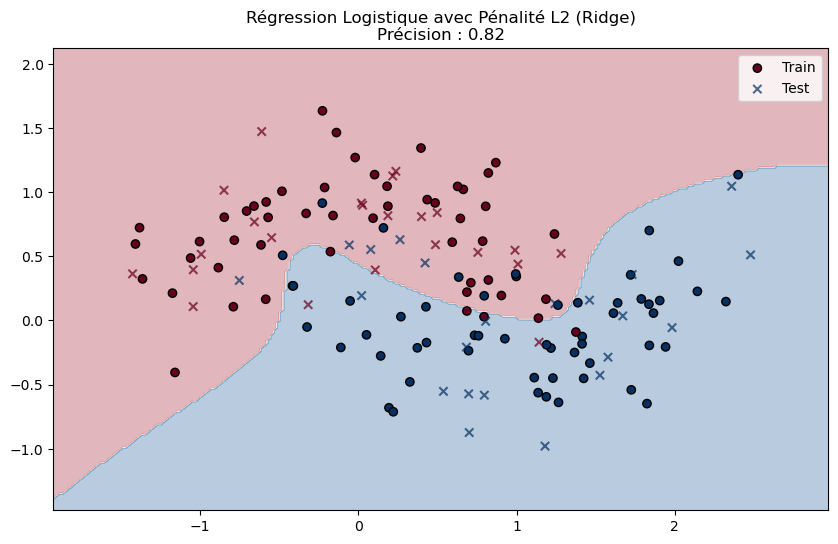

Nombre de coefficients à zéro avec L2 : 0


In [13]:
# Configuration du modèle avec pénalité L2
# Le solver 'lbfgs' est le standard pour la L2
model_l2 = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_features", PolynomialFeatures(degree=10)),
    ("logistic_regression", LogisticRegression(penalty='l2', C=1.0, solver='lbfgs'))
])

# Entraînement
model_l2.fit(X_train, y_train)

# Création de la grille pour le graphique
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model_l2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Affichage du graphique
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu', edgecolors='k', label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu', marker='x', alpha=0.7, label='Test')

plt.title(f"Régression Logistique avec Pénalité L2 (Ridge)\nPrécision : {model_l2.score(X_test, y_test):.2f}")
plt.legend()
plt.show()

# Vérification des coefficients
coeffs_l2 = model_l2.named_steps['logistic_regression'].coef_
print(f"Nombre de coefficients à zéro avec L2 : {np.sum(coeffs_l2 == 0)}")

--- Résultat pour Degré 2 ---
Nombre de features générées : 66
Précision (Accuracy) : 0.8367

--- Résultat pour Degré 3 ---
Nombre de features générées : 286
Précision (Accuracy) : 0.8600



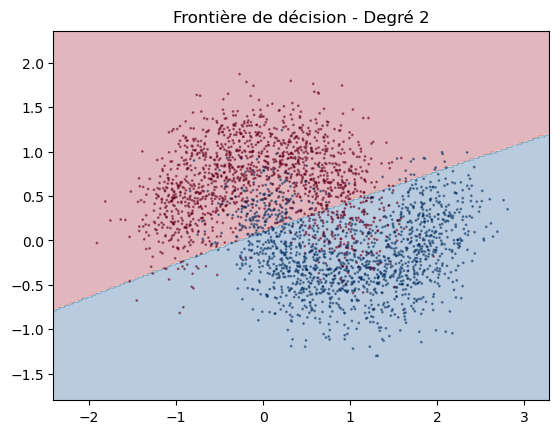

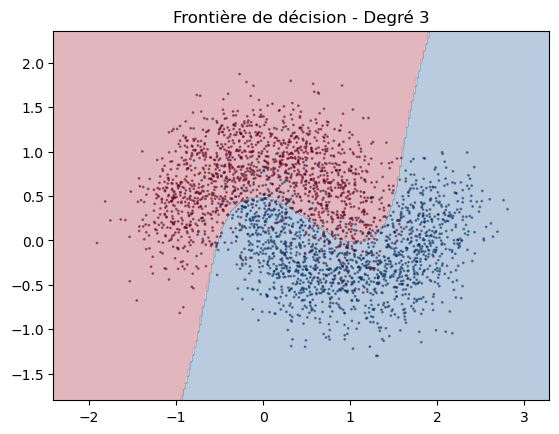

In [15]:


# 1. Génération de 3000 lignes avec 10 variables de base pour atteindre ~50 features
# On prend 2 variables "réelles" (moons) et 8 variables de bruit
X_moons, y = make_moons(n_samples=3000, noise=0.30, random_state=42)
X_noise = np.random.rand(3000, 8) 
X = np.hstack([X_moons, X_noise]) # On a maintenant 10 colonnes en entrée

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Comparaison Degré 2 et Degré 3
degrees = [2, 3]
for d in degrees:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly_features", PolynomialFeatures(degree=d)),
        ("logistic_regression", LogisticRegression(max_iter=1000))
    ])
    
    model.fit(X_train, y_train)
    n_features = model.named_steps['poly_features'].n_output_features_
    
    print(f"--- Résultat pour Degré {d} ---")
    print(f"Nombre de features générées : {n_features}")
    print(f"Précision (Accuracy) : {model.score(X_test, y_test):.4f}\n")

# 3. Visualisation (uniquement sur les 2 premières variables pour le graphique)
def plot_decision_boundary_2D(X_full, y, degree):
    # On crée un modèle qui ne s'entraîne que sur les 2 premières colonnes pour l'image
    viz_model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly_features", PolynomialFeatures(degree=degree)),
        ("logistic_regression", LogisticRegression())
    ])
    viz_model.fit(X_full[:, :2], y)
    
    x_min, x_max = X_full[:, 0].min() - 0.5, X_full[:, 0].max() + 0.5
    y_min, y_max = X_full[:, 1].min() - 0.5, X_full[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = viz_model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X_full[:, 0], X_full[:, 1], c=y, cmap='RdBu', s=1, alpha=0.5)
    plt.title(f"Frontière de décision - Degré {degree}")
    plt.show()

plot_decision_boundary_2D(X, y, 2)
plot_decision_boundary_2D(X, y, 3)

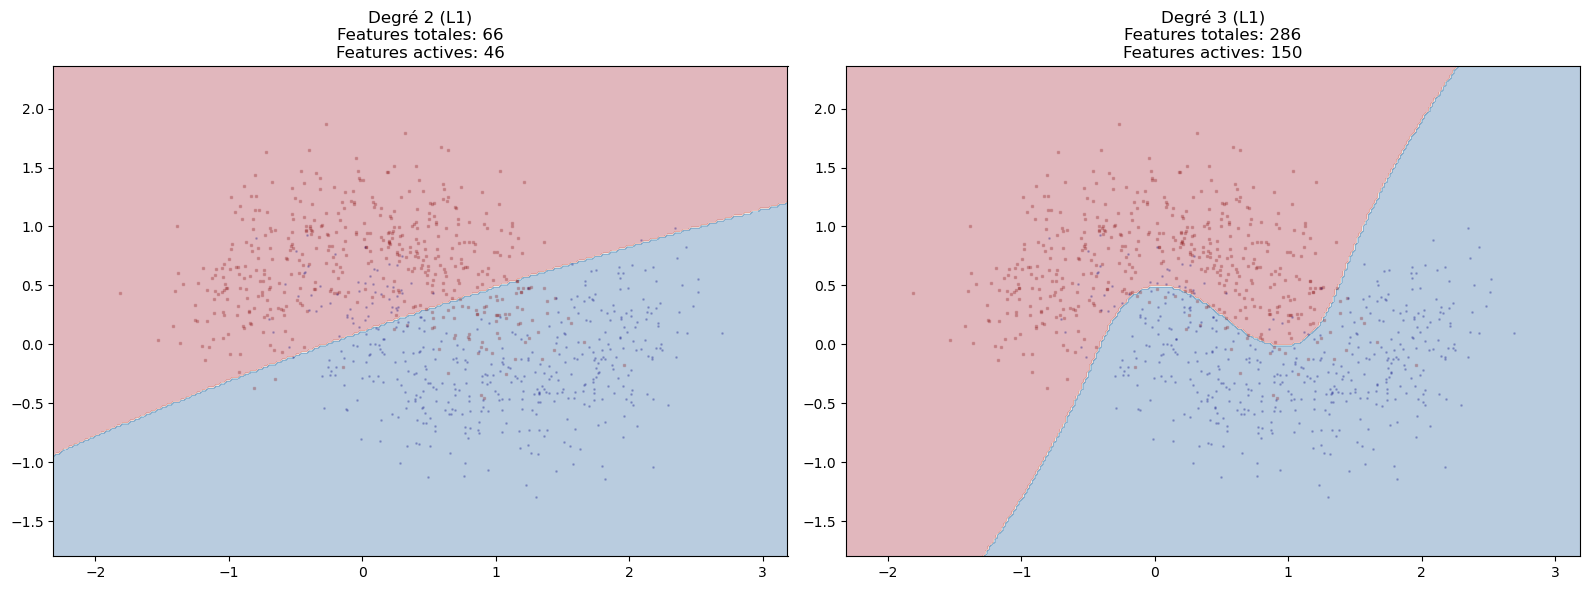

In [21]:

# 1. Préparation des données (3000 lignes, 10 colonnes au total)
X_moons, y = make_moons(n_samples=3000, noise=0.30, random_state=42)
X_noise = np.random.rand(3000, 8) 
X = np.hstack([X_moons, X_noise]) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

def plot_decision_boundary_custom(model, X_plot, y_plot, ax, title):
    # Création d'une grille basée sur les 2 premières variables (moons)
    x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
    y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    
    # Pour prédire, on doit fournir 10 colonnes au modèle (les 2 de la grille + 8 moyennes)
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    noise_padding = np.tile(np.mean(X_plot[:, 2:], axis=0), (grid_points.shape[0], 1))
    full_grid = np.hstack([grid_points, noise_padding])
    
    Z = model.predict(full_grid)
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_plot[y_plot==0, 0], X_plot[y_plot==0, 1], c='maroon', marker='s', s=1, alpha=0.2, label='Classe 0')
    ax.scatter(X_plot[y_plot==1, 0], X_plot[y_plot==1, 1], c='navy', marker='o', s=1, alpha=0.2, label='Classe 1')
    ax.set_title(title)

# 2. Génération des graphiques pour Degré 2 et 3 avec L1
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
degrees = [2, 3]

for i, d in enumerate(degrees):
    # On utilise C=0.2 pour une régularisation L1 marquée
    model_l1 = Pipeline([
        ("scaler", StandardScaler()),
        ("poly_features", PolynomialFeatures(degree=d)),
        ("logistic_regression", LogisticRegression(penalty='l1', solver='liblinear', C=0.2))
    ])
    model_l1.fit(X_train, y_train)
    
    n_feat = model_l1.named_steps['poly_features'].n_output_features_
    coefs = model_l1.named_steps['logistic_regression'].coef_
    n_active = np.sum(coefs != 0)
    
    title = f"Degré {d} (L1)\nFeatures totales: {n_feat}\nFeatures actives: {n_active}"
    plot_decision_boundary_custom(model_l1, X_test, y_test, axes[i], title)

plt.tight_layout()
plt.show()

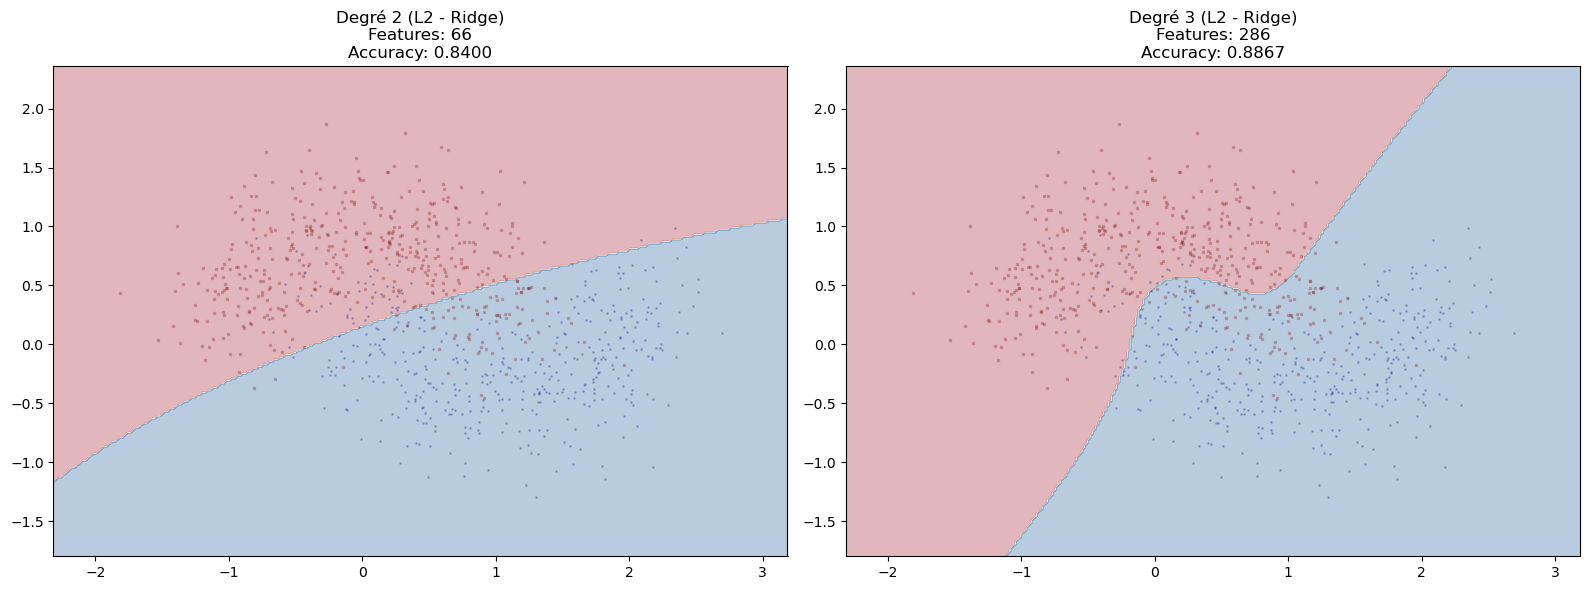

In [23]:

# 1. Préparation des données (3000 lignes, 10 colonnes pour ~50-60 features)
X_moons, y = make_moons(n_samples=3000, noise=0.30, random_state=42)
X_noise = np.random.rand(3000, 8) 
X = np.hstack([X_moons, X_noise]) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

def plot_decision_boundary_l2(model, X_plot, y_plot, ax, title):
    x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
    y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    
    # Simulation des colonnes de bruit pour la prédiction
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    noise_padding = np.tile(np.mean(X_plot[:, 2:], axis=0), (grid_points.shape[0], 1))
    full_grid = np.hstack([grid_points, noise_padding])
    
    Z = model.predict(full_grid)
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_plot[y_plot==0, 0], X_plot[y_plot==0, 1], c='maroon', marker='s', s=1, alpha=0.2)
    ax.scatter(X_plot[y_plot==1, 0], X_plot[y_plot==1, 1], c='navy', marker='o', s=1, alpha=0.2)
    ax.set_title(title)

# 2. Génération des graphiques L2
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
degrees = [2, 3]

for i, d in enumerate(degrees):
    # penalty='l2' est le défaut, C=0.1 pour une régularisation forte
    model_l2 = Pipeline([
        ("scaler", StandardScaler()),
        ("poly_features", PolynomialFeatures(degree=d)),
        ("logistic_regression", LogisticRegression(penalty='l2', C=0.1, solver='lbfgs'))
    ])
    model_l2.fit(X_train, y_train)
    
    acc = model_l2.score(X_test, y_test)
    n_feat = model_l2.named_steps['poly_features'].n_output_features_
    
    title = f"Degré {d} (L2 - Ridge)\nFeatures: {n_feat}\nAccuracy: {acc:.4f}"
    plot_decision_boundary_l2(model_l2, X_test, y_test, axes[i], title)

plt.tight_layout()
plt.show()

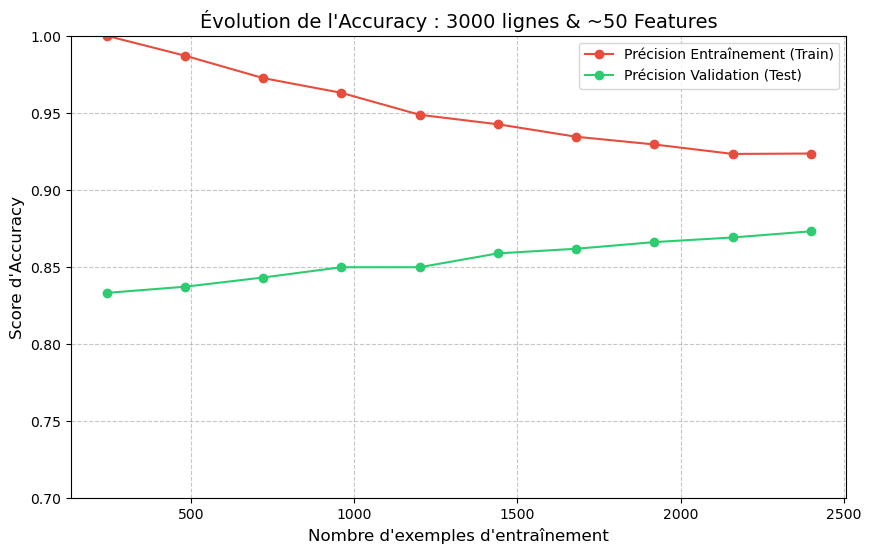

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# 1. Préparation des données (on garde nos 3000 lignes et 10 colonnes)
X_moons, y = make_moons(n_samples=3000, noise=0.30, random_state=42)
X_noise = np.random.rand(3000, 8) 
X = np.hstack([X_moons, X_noise]) 

# 2. Configuration du modèle (Degré 3 avec 50+ features au total et L2)
model_final = Pipeline([
    ("scaler", StandardScaler()),
    ("poly_features", PolynomialFeatures(degree=3)),
    ("logistic_regression", LogisticRegression(penalty='l2', C=0.1, solver='lbfgs'))
])

# 3. Calcul de la courbe d'apprentissage
# On divise le dataset en 10 paliers de taille croissante
train_sizes, train_scores, test_scores = learning_curve(
    model_final, X, y, cv=5, scoring='accuracy', n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

# Calcul des moyennes
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

# 4. Affichage du graphique d'Accuracy
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="#e74c3c", label="Précision Entraînement (Train)")
plt.plot(train_sizes, test_mean, 'o-', color="#2ecc71", label="Précision Validation (Test)")

plt.title("Évolution de l'Accuracy : 3000 lignes & ~50 Features", fontsize=14)
plt.xlabel("Nombre d'exemples d'entraînement", fontsize=12)
plt.ylabel("Score d'Accuracy", fontsize=12)
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0.7, 1.0) # On zoom sur la zone intéressante
plt.show()